In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# plt.style.use('ggplot')

$x(t)=A+Bt+C\sin(2\pi t)+w(t)$

* where ${A,B,C}$ are unknown parameters and

* $w(t)$ is white, Gaussian noise with zero mean and variance $\sigma^2 =1$.

In [2]:
# Create numpy arrays from the txt files
with open('t.txt') as f:
    t = np.array([float(num) for num in f.read().split()])

with open('x.txt') as f:
    x = np.array([float(num) for num in f.read().split()])

In [3]:
print(t)

[0.         0.02020202 0.04040404 0.06060606 0.08080808 0.1010101
 0.12121212 0.14141414 0.16161616 0.18181818 0.2020202  0.22222222
 0.24242424 0.26262626 0.28282828 0.3030303  0.32323232 0.34343434
 0.36363636 0.38383838 0.4040404  0.42424242 0.44444444 0.46464646
 0.48484848 0.50505051 0.52525253 0.54545455 0.56565657 0.58585859
 0.60606061 0.62626263 0.64646465 0.66666667 0.68686869 0.70707071
 0.72727273 0.74747475 0.76767677 0.78787879 0.80808081 0.82828283
 0.84848485 0.86868687 0.88888889 0.90909091 0.92929293 0.94949495
 0.96969697 0.98989899 1.010101   1.030303   1.0505051  1.0707071
 1.0909091  1.1111111  1.1313131  1.1515152  1.1717172  1.1919192
 1.2121212  1.2323232  1.2525253  1.2727273  1.2929293  1.3131313
 1.3333333  1.3535354  1.3737374  1.3939394  1.4141414  1.4343434
 1.4545455  1.4747475  1.4949495  1.5151515  1.5353535  1.5555556
 1.5757576  1.5959596  1.6161616  1.6363636  1.6565657  1.6767677
 1.6969697  1.7171717  1.7373737  1.7575758  1.7777778  1.7979798
 1.

In [6]:
print(x)

[ 1.2696486   1.9144685   0.35113102  1.2159351   2.1732114   3.0904026
  4.4413977   3.3213046   5.1339593   4.5679572   5.4428639   4.5258148
  3.8246346   3.0344178   4.6575529   5.2596144   4.0418578   3.6437918
  3.6858796   2.6713905   3.0162506   3.0424251   2.9607904   2.5264414
  2.8662003   2.0242349   3.3905163   1.5577352   2.7330153  -0.09243648
  0.88419129 -0.14580812  0.50578628  0.32918792 -2.5793471  -1.8044282
 -1.9559325  -0.10282839  1.0240394  -0.66649136  0.62604104  0.55774567
 -0.79839047  0.93106561  0.09752021  2.7125263   1.5366346   3.5988892
  1.9465817   3.3789596   3.1476826   1.6064009   3.0549789   5.0433102
  4.7488545   4.031853    4.8400228   5.9962759   4.9947754   7.1612322
  5.6989676   8.2550245   5.4248066   6.7141083   4.9563585   5.6696944
  5.6714926   6.4956926   6.8276906   5.9428417   4.9962443   5.886967
  5.5531756   4.5437044   4.6563304   4.1579309   2.4228136   3.844619
  2.1196343   1.8868211   2.4089631   1.6979751   1.6836014   2.

Observation Matrix given by


$H =  \begin{bmatrix}
   1 & t_{0} & \cdots & \sin(2\pi t_{0}) \\
   1 & t_{1} & \cdots & \sin(2\pi t_{1}) \\
   \vdots  & \vdots  & \ddots & \vdots  \\
   1 & t_{N-1} & \cdots & \sin(2\pi t_{N-1})
 \end{bmatrix}$

In [4]:
# Generate observation matrix H
H_matrix = np.array([[1, time, np.sin(2 * np.pi * time)] for time in t])
print(H_matrix)

[[ 1.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 1.00000000e+00  2.02020200e-02  1.26592452e-01]
 [ 1.00000000e+00  4.04040400e-02  2.51147985e-01]
 [ 1.00000000e+00  6.06060610e-02  3.71662458e-01]
 [ 1.00000000e+00  8.08080810e-02  4.86196737e-01]
 [ 1.00000000e+00  1.01010100e-01  5.92907924e-01]
 [ 1.00000000e+00  1.21212120e-01  6.90079006e-01]
 [ 1.00000000e+00  1.41414140e-01  7.76146459e-01]
 [ 1.00000000e+00  1.61616160e-01  8.49725425e-01]
 [ 1.00000000e+00  1.81818180e-01  9.09631991e-01]
 [ 1.00000000e+00  2.02020200e-01  9.54902238e-01]
 [ 1.00000000e+00  2.22222220e-01  9.84807751e-01]
 [ 1.00000000e+00  2.42424240e-01  9.98867338e-01]
 [ 1.00000000e+00  2.62626260e-01  9.96854777e-01]
 [ 1.00000000e+00  2.82828280e-01  9.78802450e-01]
 [ 1.00000000e+00  3.03030300e-01  9.45000825e-01]
 [ 1.00000000e+00  3.23232320e-01  8.95993783e-01]
 [ 1.00000000e+00  3.43434340e-01  8.32569867e-01]
 [ 1.00000000e+00  3.63636360e-01  7.55749589e-01]
 [ 1.00000000e+00  3.83838380e-

In [5]:
# Matrix operations
H_T = np.transpose(H_matrix)
H_T_H = np.matmul(H_T, H_matrix)
H_T_H_inv = np.linalg.inv(H_T_H)

theta_est = np.matmul(np.matmul(H_T_H_inv, H_T), np.transpose(x))
print(theta_est)

[1.00226431 2.01326348 2.90994075]


In [6]:
def estimator(time):
    return theta_est[0] + theta_est[1] * time + \
        theta_est[2] * np.sin(2 * np.pi * time)

# Generate estimates for each time step
x_est = np.array([estimator(time) for time in t])

print("Covariance matrix:")
print(H_T_H_inv)

Covariance matrix:
[[ 0.04447705 -0.03447705 -0.01095965]
 [-0.03447705  0.03447705  0.01095965]
 [-0.01095965  0.01095965  0.0236859 ]]


In [7]:
# CRLB
CRLB = np.diag(H_T_H_inv)
print(CRLB)

[0.04447705 0.03447705 0.0236859 ]


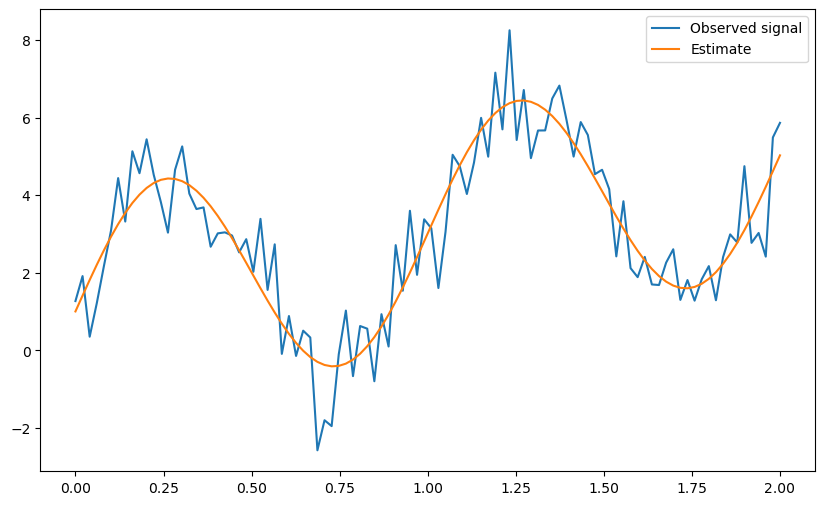

In [8]:
plt.figure(figsize=(10,6)) #dpi=150,
plt.plot(t, x)
plt.plot(t, x_est)
plt.legend(['Observed signal', 'Estimate'])
plt.show()